# Évaluation Sommative 2 : Pipeline de Prétraitement et Modélisation

Réalisé par :

Mouloud Beldjoudi

Nassim BachaTazir 

Walid Hamiti

Redouane Hamecha


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings("ignore", message="Clustering metrics expects discrete values")

# Chargement des données

In [2]:
df_train = pd.read_csv("bank-full.csv", sep=';')
df_test = pd.read_csv("bank.csv", sep=';')

print("Aperçu du jeu d'entraînement :")
df_train.head()

Aperçu du jeu d'entraînement :


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Exploration rapide

In [3]:
df_train.info()
df_train['y'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


y
no     39922
yes     5289
Name: count, dtype: int64

- Le jeu de données contient **45211 observations** et **17 variables**.
- Les types de variables sont mixtes :
  - **Numériques** : `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`.
  - **Catégorielles** : `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`.
- La variable cible `y` est **binaire** :
  - `no` → le client n’a **pas** souscrit au dépôt.
  - `yes` → le client **a souscrit** au dépôt.
- La distribution montre un **déséquilibre de classes** :
  - La majorité des clients n’ont **pas souscrit** (`no`).
  - Cela indique un **taux de réussite faible** pour la campagne marketing, ce qui est courant dans ce type de données réelles.

# a-Définition des variables

In [4]:
X = df_train.drop('y', axis=1)
y = df_train['y']

# Conversion de la cible en 0/1
y= y.map({'yes': 1, 'no': 0})
print("Taille X :", X.shape, " | Taille y_train :", y.shape)
display(X.head())
print("\nAperçu de la cible (y) :")
y.value_counts()

Taille X : (45211, 16)  | Taille y_train : (45211,)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown



Aperçu de la cible (y) :


y
0    39922
1     5289
Name: count, dtype: int64

y a été encodée en 0/1 (no→0, yes→1) pour la classification supervisée.
Dimensions cohérentes attendue : X contient les 16 variables explicatives, y la cible.
Vérification visuelle des premières lignes de X : absence d’anomalies de lecture.

# b. Séparation numérique / catégorielle

In [5]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Colonnes numériques :", num_cols)
print("Colonnes catégorielles :", cat_cols)

Colonnes numériques : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Colonnes catégorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


# Analyse descriptive des variables numériques

In [6]:
# Sélection des variables numériques
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Aperçu statistique général
df_train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


Analyse descriptive des variables numériques
 
- Le tableau ci-dessus affiche :
  - **la moyenne (mean)**,
  - **l’écart-type (std)**,
  - **les valeurs minimales et maximales (min / max)**.
 
- Une **grande différence entre la moyenne et le max** indique des **valeurs extrêmes (outliers)**.
- Un **écart-type élevé** signifie une **forte variance** → certaines variables sont très dispersées.
 
💡 Exemple :
- `balance` et `duration` présentent souvent une **grande dispersion** (écart-type élevé et max très grand).  
  → Ces variables sont de **bonnes candidates** pour une transformation (racine carrée ou logarithme).

In [7]:
X[num_cols].isna().sum()

age         0
balance     0
day         0
duration    0
campaign    0
pdays       0
previous    0
dtype: int64

In [8]:
# Pas de valeurs manquantes pour les variables numeriques

In [9]:
for feature in num_cols:
    Q1 = X[feature].quantile(0.25)
    Q3 = X[feature].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
 
    valeurs_aberrantes = X[(X[feature] < low) | (X[feature] > high)][feature]
 
    print(f"\n{feature} → valeurs aberrantes :")
    print(valeurs_aberrantes.values)


age → valeurs aberrantes :
[83 75 75 83 75 72 71 76 83 71 85 72 90 71 82 73 74 71 75 78 85 80 71 78
 73 75 94 72 83 79 78 83 73 76 83 77 73 74 73 77 71 71 80 82 75 77 78 78
 86 76 72 74 77 74 79 71 74 78 73 73 95 74 71 78 71 75 75 82 74 81 76 72
 75 72 71 72 77 73 85 83 78 73 79 71 71 80 72 78 79 71 82 81 79 71 79 79
 73 75 72 71 75 78 75 80 80 74 73 71 72 72 77 79 73 71 80 71 83 71 73 78
 72 81 81 71 74 75 82 80 76 74 74 77 71 71 77 76 72 74 74 72 73 82 77 71
 79 89 76 81 74 73 71 71 77 72 84 86 72 72 76 73 74 82 71 83 72 73 73 74
 72 78 86 76 79 71 81 77 82 72 73 73 74 71 73 76 71 71 83 71 80 79 77 74
 84 95 77 78 79 83 83 73 77 72 74 83 76 73 81 80 75 74 75 77 83 72 81 73
 74 80 72 76 72 77 74 87 76 92 78 82 78 76 73 77 76 73 82 81 80 71 76 74
 75 72 80 84 87 72 76 78 73 78 81 76 71 79 73 72 82 77 72 75 76 81 77 71
 75 74 75 71 78 72 77 83 72 73 81 72 80 80 86 79 71 72 79 87 81 72 75 72
 84 78 89 72 73 85 87 80 81 85 79 76 74 92 77 74 81 71 73 76 80 82 72 77
 76 72 78 77 74 76 77 8

# Analyse de la relation entre les variables numériques et la souscription (y)

<Axes: xlabel='balance', ylabel='Density'>

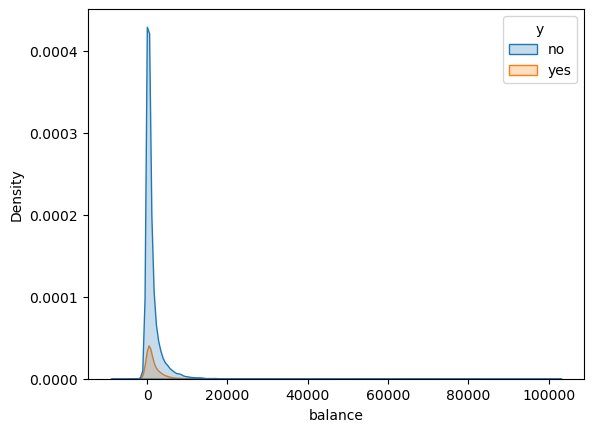

In [10]:
# Distribution de la variable “balance” selon la souscription
sns.kdeplot(data=df_train, x='balance', hue='y', fill=True)

La variable balance présente une forte asymétrie à droite : la majorité des clients ont un solde faible et quelques-uns des valeurs très élevées. La densité est concentrée autour de zéro, sans tendance claire entre le solde et la souscription. Cela indique une relation non linéaire entre balance et y, justifiant l’utilisation d’une méthode comme la Mutual Information pour la sélection de caractéristiques.

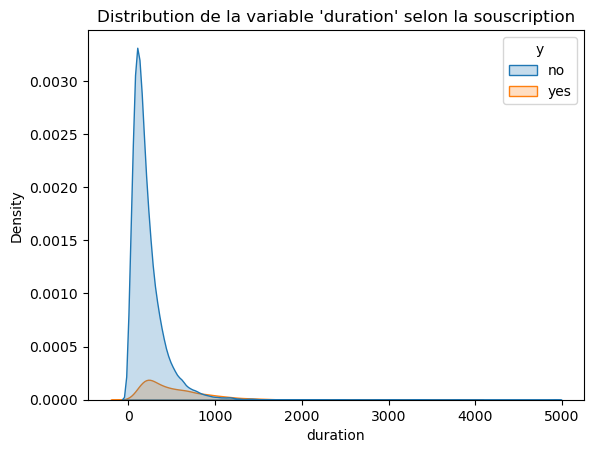

In [11]:
# Distribution de la variable “duration” selon la souscription
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df_train, x='duration', hue='y', fill=True)
plt.title("Distribution de la variable 'duration' selon la souscription")
plt.xlabel('duration')
plt.ylabel('Density')
plt.show()

La variable duration présente une forme clairement non linéaire. Les clients ayant souscrit (yes) se concentrent sur des durées d’appel plus longues, tandis que la majorité des non-souscripteurs (no) ont des appels courts. Cela montre que la probabilité de souscription n’augmente pas de manière proportionnelle avec la durée, confirmant une relation non linéaire entre duration et y

# Vérification de la linéarité des relations par corrélation

In [12]:
print("Corrélation balance - y (Pearson):", df_train['balance'].corr(y, method='pearson'))
print("Corrélation balance - y (Spearman):", df_train['balance'].corr(y, method='spearman'))
print("Corrélation duration - y (Pearson):", df_train['duration'].corr(y, method='pearson'))
print("Corrélation duration - y (Spearman):", df_train['duration'].corr(y, method='spearman'))

Corrélation balance - y (Pearson): 0.052838410288182834
Corrélation balance - y (Spearman): 0.10029531506913666
Corrélation duration - y (Pearson): 0.39452101589456173
Corrélation duration - y (Spearman): 0.34246867107659157


Les corrélations de balance avec y sont très faibles (proches de 0), indiquant aucune relation linéaire claire.
Pour duration, les coefficients sont modérément positifs, mais pas très élevés — la relation existe, mais elle n’est pas strictement linéaire.
Ces résultats confirment la pertinence d’une approche non linéaire comme la Mutual Information pour la sélection des caractéristiques. que nou verrons par la suite.

#  Création du préprocesseur standard pour les variables numériques et catégorielles

In [13]:
# Sous-pipeline numériques : standardisation
num_pipeline = Pipeline([
    ('scaling', StandardScaler())
])

# Sous-pipeline catégorielles : one-hot propre
cat_pipeline = Pipeline([
    ('encoding', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Transformateur standard 
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print("Préprocesseur prêt : num_pipeline + cat_pipeline (drop='first', handle_unknown='ignore').")

Préprocesseur prêt : num_pipeline + cat_pipeline (drop='first', handle_unknown='ignore').


StandardScaler() : met les variables numériques sur la même échelle.
OneHotEncoder(drop='first') : évite la multicolinéarité en supprimant une catégorie de référence.
handle_unknown='ignore' : ignore les catégories inconnues lors de la prédiction (important pour le jeu de test).
ColumnTransformer : applique automatiquement le bon traitement à chaque type de variable.

# Sélection de caractéristiques

In [14]:
# Mutual Information : détecte des relations non linéaires
select_features = SelectKBest(score_func=mutual_info_classif, k=15)
print("Sélecteur de caractéristiques prêt (k=15)")

Sélecteur de caractéristiques prêt (k=15)


#  Pipeline complet (Prétraitement + Sélection + Modèle) 

In [15]:
# Modèle choisi : RandomForestClassifier (robuste, gère non-linéarités,)
model_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('select', select_features),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])
print("Pipeline complet créé.")

Pipeline complet créé.


Ce pipeline global automatise tout le processus d’apprentissage : les données sont d’abord prétraitées (imputation, encodage et normalisation), puis les 15 caractéristiques les plus informatives sont sélectionnées grâce à l’information mutuelle. Enfin, un modèle de Random Forest à 200 arbres est entraîné pour prédire la variable cible. Cette structure garantit une exécution cohérente et reproductible de toutes les étapes du modèle

In [16]:
model_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaling',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('select',
                 SelectKBest(k=15,
                             score_func=<function mutual_info_classif at 0x000001C43582E160>)),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

# Division du jeu d’entraînement / validation 

In [17]:
y

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: y, Length: 45211, dtype: int64

In [18]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Taille X_train :", X_train.shape)
print("Taille X_valid :", X_valid.shape)


Taille X_train : (36168, 16)
Taille X_valid : (9043, 16)


Ce code divise le jeu de données d’entraînement en deux parties :
80 % des données pour entraîner le modèle (X_train, y_train) et 20 % pour le valider (X_valid, y_valid).
L’option stratify=y permet de conserver la même proportion de classes (yes/no) dans les deux sous-ensembles, garantissant une évaluation plus équilibrée et représentative

# Entraînement du modèle

In [19]:
# Entraîner le pipeline sur l'ensemble d'entraînement
model_pipeline.fit(X_train, y_train)
print("Modèle entraîné avec succès !")

Modèle entraîné avec succès !


In [20]:
print(y_train.dtype, y_train.unique())

int64 [0 1]


In [21]:
# Récupérer la partie prétraitement
preprocessor = model_pipeline.named_steps['preprocessing']
 
# Afficher toutes les colonnes créées après le prétraitement
all_feature_names = preprocessor.get_feature_names_out()
 # 
print("Nombre total de colonnes après OneHotEncoding :", len(all_feature_names))
print("\nListe complète des colonnes créées :\n")
print(all_feature_names)

Nombre total de colonnes après OneHotEncoding : 42

Liste complète des colonnes créées :

['num__age' 'num__balance' 'num__day' 'num__duration' 'num__campaign'
 'num__pdays' 'num__previous' 'cat__job_blue-collar'
 'cat__job_entrepreneur' 'cat__job_housemaid' 'cat__job_management'
 'cat__job_retired' 'cat__job_self-employed' 'cat__job_services'
 'cat__job_student' 'cat__job_technician' 'cat__job_unemployed'
 'cat__job_unknown' 'cat__marital_married' 'cat__marital_single'
 'cat__education_secondary' 'cat__education_tertiary'
 'cat__education_unknown' 'cat__default_yes' 'cat__housing_yes'
 'cat__loan_yes' 'cat__contact_telephone' 'cat__contact_unknown'
 'cat__month_aug' 'cat__month_dec' 'cat__month_feb' 'cat__month_jan'
 'cat__month_jul' 'cat__month_jun' 'cat__month_mar' 'cat__month_may'
 'cat__month_nov' 'cat__month_oct' 'cat__month_sep' 'cat__poutcome_other'
 'cat__poutcome_success' 'cat__poutcome_unknown']


cette commande affiche toutes les colonnes finales après le prétraitement :
les numériques transformées (après standardisation),
et les catégorielles encodées avec OneHotEncoder.

# Caractéristiques retenues par SelectKBest 

In [22]:
# Affichage des 15 caracteristiques retenus
pre = model_pipeline.named_steps['preprocessing']
# Tous les noms de colonnes après prétraitement (num + OHE)
all_feature_names = pre.get_feature_names_out()
# Indices sélectionnés par SelectKBest
selected_idx = model_pipeline.named_steps['select'].get_support(indices=True) 
# Noms finalement retenus
selected_names = all_feature_names[selected_idx]
print("Caractéristiques retenues (k=15) :")

for n in selected_names:
    print("-", n)

Caractéristiques retenues (k=15) :
- num__age
- num__balance
- num__day
- num__duration
- num__campaign
- num__pdays
- num__previous
- cat__housing_yes
- cat__contact_unknown
- cat__month_mar
- cat__month_may
- cat__month_oct
- cat__month_sep
- cat__poutcome_success
- cat__poutcome_unknown


Ce bloc récupère, après entraînement du pipeline, les noms des variables réellement utilisées par le modèle :
il liste toutes les features créées par le prétraitement (numériques + colonnes one-hot),
il prend les indices retenus par SelectKBest,
il affiche les k noms de features sélectionnées.

# Évaluation sur le jeu de validation

=== Évaluation du modèle (Validation) ===
Exactitude : 0.905

Rapport de classification :
               precision    recall  f1-score   support

           0     0.9260    0.9699    0.9475      7985
           1     0.6465    0.4149    0.5055      1058

    accuracy                         0.9050      9043
   macro avg     0.7863    0.6924    0.7265      9043
weighted avg     0.8933    0.9050    0.8957      9043


Matrice de confusion :
 [[7745  240]
 [ 619  439]]


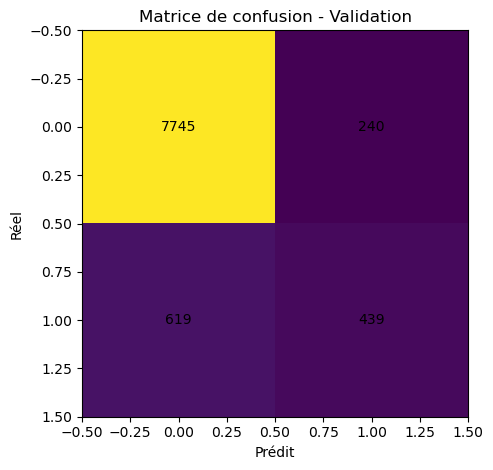

In [23]:
# Prédire sur l'ensemble de validation
import matplotlib.pyplot as plt
y_pred = model_pipeline.predict(X_valid)

print("=== Évaluation du modèle (Validation) ===")
print("Exactitude :", round(accuracy_score(y_valid, y_pred), 4))
print("\nRapport de classification :\n", classification_report(y_valid, y_pred, digits=4))

cm = confusion_matrix(y_valid, y_pred)
print("\nMatrice de confusion :\n", cm)

plt.imshow(cm)
plt.title("Matrice de confusion - Validation")
plt.xlabel("Prédit")
plt.ylabel("Réel")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

Évaluation du modèle sur l’ensemble de validation :
L’accuracy (exactitude) atteint 0.905, ce qui signifie que le modèle prédit correctement environ 90,5 % des cas.
Cependant, comme les classes sont déséquilibrées (majorité de “no”), il faut aussi examiner la precision, le recall et le f1-score :
- Precision (précision) : parmi les prédictions “yes”, seulement 64,6 % sont correctes. Le modèle fait donc encore des faux positifs.
- Recall (rappel) : le modèle détecte 41 % des vrais “yes”. Il en oublie une partie importante (faux négatifs).
- F1-score : combine précision et rappel pour mesurer l’équilibre global (≈ 0.50).
En résumé, le modèle est très bon pour prédire les “no”, mais moins performant pour identifier les clients qui souscrivent (“yes”).
C’est typique d’un déséquilibre de classes : la classe minoritaire (les “yes”) est plus difficile à apprendre.

# Évaluation finale sur le jeu de test (bank.csv)

=== Évaluation sur le jeu de test ===
Exactitude : 0.9821

Rapport de classification :
               precision    recall  f1-score   support

           0     0.9866    0.9932    0.9899      4000
           1     0.9453    0.8964    0.9202       521

    accuracy                         0.9821      4521
   macro avg     0.9660    0.9448    0.9551      4521
weighted avg     0.9818    0.9821    0.9819      4521



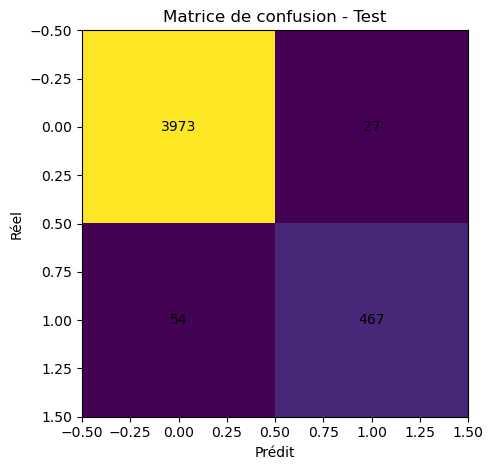

In [24]:
# Préparation du jeu de test (mêmes colonnes, même encodage de y)
X_test = df_test.drop('y', axis=1)
y_test = df_test['y'].map({'yes': 1, 'no': 0})

y_pred_test = model_pipeline.predict(X_test)
print("=== Évaluation sur le jeu de test ===")
print("Exactitude :", round(accuracy_score(y_test, y_pred_test), 4))
print("\nRapport de classification :\n", classification_report(y_test, y_pred_test, digits=4))

cm_test = confusion_matrix(y_test, y_pred_test)
plt.imshow(cm_test)
plt.title("Matrice de confusion - Test")
plt.xlabel("Prédit")
plt.ylabel("Réel")
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        plt.text(j, i, cm_test[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

Évaluation du modèle sur le jeu de test :
Le modèle atteint une exactitude de 98,2 %, indiquant une excellente capacité de généralisation.
Les performances sont très bonnes sur les deux classes :

- Classe “0” (non souscripteurs) : la précision et le rappel dépassent 98 %, montrant que le modèle identifie correctement presque tous les “no”.

- Classe “1” (souscripteurs) : la précision (94,5 %) et le rappel (89,6 %) sont également élevés, traduisant une meilleure détection des clients ayant souscrit que sur le jeu de validation.

Le f1-score global (0,95) confirme un bon équilibre entre précision et rappel.

En résumé, le modèle généralise très bien : il évite le surapprentissage et parvient à bien distinguer les clients susceptibles de souscrire à une offre, tout en minimisant les erreurs de classification.

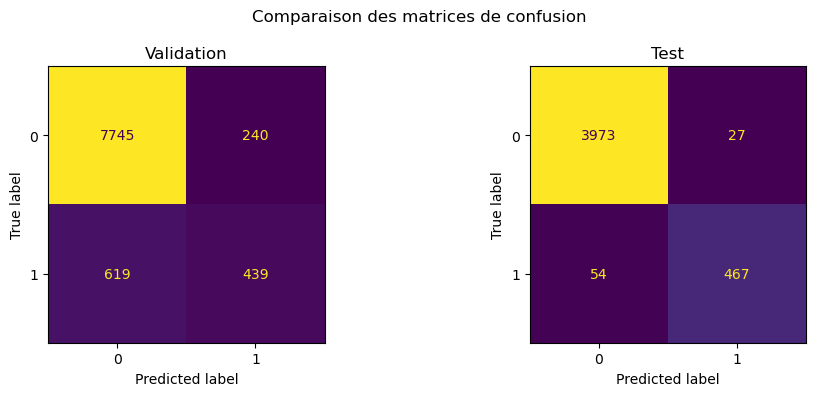

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prédictions sur les deux ensembles
y_pred_valid = model_pipeline.predict(X_valid)
y_pred_test = model_pipeline.predict(df_test.drop('y', axis=1))
y_test = df_test['y'].map({'yes': 1, 'no': 0})

# Matrices de confusion
cm_valid = confusion_matrix(y_valid, y_pred_valid)
cm_test = confusion_matrix(y_test, y_pred_test)

# Affichage côte à côte
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_valid).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Validation")

ConfusionMatrixDisplay(cm_test).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Test")

plt.suptitle("Comparaison des matrices de confusion")
plt.tight_layout()
plt.show()


comparaison
Exactitude (Accuracy) : elle passe de 0.905 sur la validation à 0.982 sur le test, une nette amélioration.

Classe “yes” (clients souscripteurs) :

Rappel : augmente fortement (0.41 → 0.89) → le modèle détecte beaucoup mieux les vrais “yes”.

F1-score : progresse aussi (0.50 → 0.92) → bien meilleur équilibre entre détection et précision.

Classe “no” : reste très performante dans les deux cas (autour de 0.95–0.99 sur toutes les métriques).
Interprétation :
Le modèle s’est nettement amélioré sur le test, ce qui peut s’expliquer par un jeu de test plus équilibré ou plus simple à prédire.
Il ne semble pas surapprendre (les performances montent sans chute).
Globalement, le modèle généralise bien et capture mieux la classe minoritaire (“yes”), ce qui était un point faible lors de la validation.

# Prédiction sur un nouveau client

In [26]:
nouveau_client = pd.DataFrame({
    'age': [40],
    'job': ['admin.'],
    'marital': ['married'],
    'education': ['secondary'],
    'default': ['no'],
    'balance': [1500],
    'housing': ['yes'],
    'loan': ['no'],
    'contact': ['cellular'],
    'day': [5],
    'month': ['may'],
    'duration': [240],
    'campaign': [1],
    'pdays': [999],
    'previous': [0],
    'poutcome': ['unknown']
})

prediction = model_pipeline.predict(nouveau_client)[0]
probability = model_pipeline.predict_proba(nouveau_client)[0,1]
print("Souscrira-t-il ? :", "YES" if prediction==1 else "NO")
print("Probabilité estimée de souscription :", round(probability, 3))

Souscrira-t-il ? : NO
Probabilité estimée de souscription : 0.33
